# 2. IMD on hidden states of 01

Follow `imd_tutorial.ipynb` and apply it to the point cloud (hidden states of the head-direction RNN from notebook 01).

**point cloud → ring → graph → drift and covariance (CDC) → IMD trajectories → angle diffusion.**

The estimated manifold is saved at the end of section 5 and reused by notebook 03.

In [1]:
from pathlib import Path
import sys
sys.dont_write_bytecode = True  # ne pas écrire de .pyc dans src/ du tutoriel (hors ProjMa2)
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
from scipy.sparse.csgraph import connected_components
from sklearn.decomposition import PCA
from ripser import ripser

# notebook lancé depuis ProjMa2/notebooks
PROJ = Path.cwd().parent        # ProjMa2
ROOT = PROJ.parent              # racine du dépôt (contient src/ du tutoriel IMD)
sys.path.insert(0, str(ROOT))

from src import (proximity_graph, graph_generator, drift_and_cdc,
                 make_coefficient_lookup, euler_maruyama)
from src.plotting import plot_diffusion_3D

## 1. Load hidden states and remove the transient

Each sequence starts from $h_0=\tanh(W_\text{enc}[\cos\theta_0,\sin\theta_0])$, which is not on the stationary manifold: the state needs a few dozen steps to reach it. Measure the mean distance of $h_t$ to the cloud of late states ($t\geq300$), and remove the first 50 steps (`BURN_IN`), before this distance levels off.

hidden_states: (500, 600, 64)


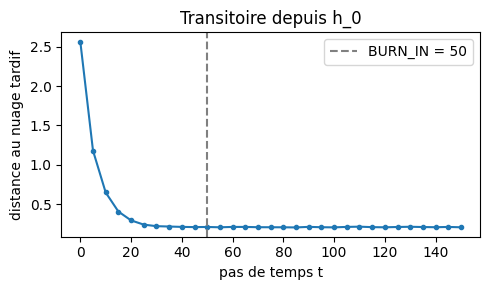

In [2]:
data = np.load(PROJ / "data" / "simulated" / "head_direction_trajectories_ring.npz")
hidden_states, theta, velocity = data["hidden_states"], data["theta"], data["velocity"][..., 0]
n_seq, seq_len, hidden_size = hidden_states.shape
print("hidden_states:", hidden_states.shape)

late_tree = cKDTree(hidden_states[:, 300:].reshape(-1, hidden_size)[::50])
steps = np.arange(0, 151, 5)
dist_to_late = [late_tree.query(hidden_states[:, t])[0].mean() for t in steps]

BURN_IN = 50
plt.figure(figsize=(5, 3))
plt.plot(steps, dist_to_late, "o-", ms=3)
plt.axvline(BURN_IN, color="gray", ls="--", label=f"BURN_IN = {BURN_IN}")
plt.xlabel("pas de temps t")
plt.ylabel("distance au nuage tardif")
plt.title("Transitoire depuis h_0")
plt.legend()
plt.tight_layout()
plt.show()

## 2. The ring

Project on the principal components and check what each one encodes (correlation with $\cos\theta$, $\sin\theta$ and the velocity). Expected: PC1–2 ≈ $(\cos\theta,\sin\theta)$ up to a rotation (the ring), and PC3 ≈ angular velocity.

variance expliquée: [0.405 0.375 0.116 0.031 0.028]
PC1: corr cos θ -0.66, sin θ +0.74, vitesse +0.05
PC2: corr cos θ -0.73, sin θ -0.67, vitesse +0.11
PC3: corr cos θ +0.12, sin θ +0.02, vitesse +0.97
PC4: corr cos θ +0.05, sin θ -0.07, vitesse -0.07


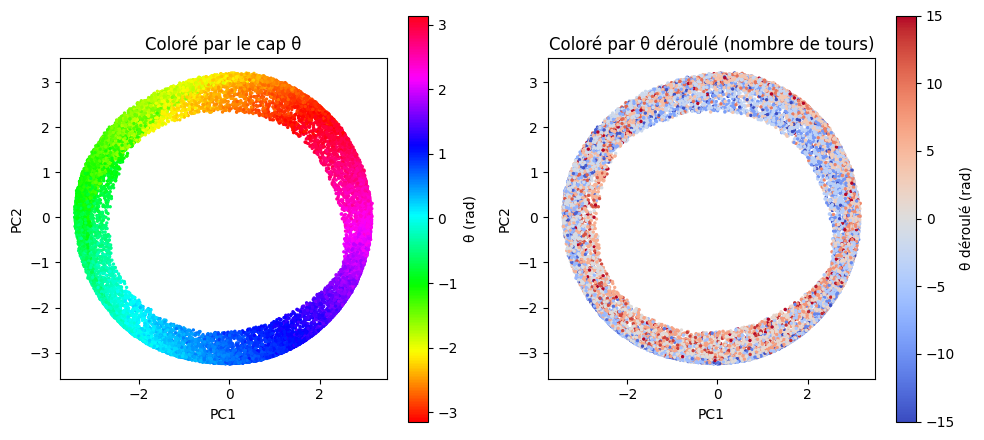

In [3]:
H_all = hidden_states[:, BURN_IN:].reshape(-1, hidden_size)
theta_all = np.angle(np.exp(1j * theta[:, BURN_IN:].reshape(-1)))  # cap replié dans [-pi, pi)
theta_unwrapped = theta[:, BURN_IN:].reshape(-1)
vel_all = velocity[:, BURN_IN:].reshape(-1)

pca = PCA(n_components=10).fit(H_all[::10])
print("variance expliquée:", pca.explained_variance_ratio_[:5].round(3))
sub = np.random.default_rng(0).choice(len(H_all), 20000, replace=False)
Z = pca.transform(H_all[sub])
for j in range(4):
    c = lambda y: np.corrcoef(Z[:, j], y)[0, 1]
    print(f"PC{j+1}: corr cos θ {c(np.cos(theta_all[sub])):+.2f}, sin θ {c(np.sin(theta_all[sub])):+.2f}, "
          f"vitesse {c(vel_all[sub]):+.2f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
sc = axes[0].scatter(Z[:, 0], Z[:, 1], c=theta_all[sub], cmap="hsv", s=2)
axes[0].set(xlabel="PC1", ylabel="PC2", title="Coloré par le cap θ", aspect="equal")
plt.colorbar(sc, ax=axes[0], label="θ (rad)")
sc = axes[1].scatter(Z[:, 0], Z[:, 1], c=theta_unwrapped[sub], cmap="coolwarm", s=2, vmin=-15, vmax=15)
axes[1].set(xlabel="PC1", ylabel="PC2", title="Coloré par θ déroulé (nombre de tours)", aspect="equal")
plt.colorbar(sc, ax=axes[1], label="θ déroulé (rad)")
plt.tight_layout()
plt.show()

**Persistent homology**: a ring has one connected component and a single persistent H1 loop; the other bars are close to 0.

5 plus grandes persistances H1 (PC1–2): [4.29 0.16 0.15 0.14 0.13]


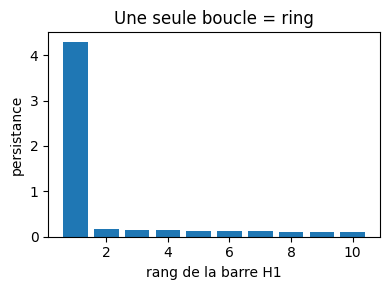

In [4]:
ring_sample = Z[:1500, :2]
h1 = ripser(ring_sample, maxdim=1)["dgms"][1]
h1_persistence = np.sort(h1[:, 1] - h1[:, 0])[::-1]
print("5 plus grandes persistances H1 (PC1–2):", h1_persistence[:5].round(2))

plt.figure(figsize=(4, 3))
plt.bar(np.arange(1, 11), h1_persistence[:10])
plt.xlabel("rang de la barre H1")
plt.ylabel("persistance")
plt.title("Une seule boucle = ring")
plt.tight_layout()
plt.show()

### Is the ring an attractor?

With velocity input, the states fill a thin cylinder (ring × velocity, section 3). The 1D object, the "closed line", should be the **attractor**: with zero velocity, the state should fall back onto the ring and stay there, whatever the angle (continuous attractor).

Test: start from 200 states of the cloud (taken mid-sequence, so with various velocities) and run the RNN for **10 s with zero velocity**. Expected:

- the spread along PC3 (velocity) collapses → the state falls back onto the ring;
- the decoded angle barely drifts;
- the final states cover the whole ring (not a few isolated fixed points).

In [ ]:
import torch
sys.path.append(str(PROJ / "src" / "rnn"))
from model import HeadDirectionRNN

model = HeadDirectionRNN(hidden_size=hidden_size, init_from_heading=True)
model.load_state_dict(torch.load(PROJ / "results" / "models" / "head_direction_rnn_ring.pt", map_location="cpu"))
model.eval()

N_RELAX, T_RELAX = 200, 500   # 500 steps of 20 ms = 10 s with zero velocity
start_seq = np.random.default_rng(3).choice(n_seq, N_RELAX, replace=False)
starts = hidden_states[start_seq, 300]
with torch.no_grad():
    readout, h_relax = model(torch.zeros(N_RELAX, T_RELAX, 1), h0=torch.from_numpy(starts)[None])
h_relax = np.concatenate([starts[:, None], h_relax.numpy()], axis=1)
Z_relax = pca.transform(h_relax.reshape(-1, hidden_size)).reshape(N_RELAX, T_RELAX + 1, -1)
heading = np.unwrap(np.arctan2(readout[..., 1], readout[..., 0]).numpy(), axis=1)
heading_drift = np.abs(heading - heading[:, :1])

pc3_spread = Z_relax[:, :, 2].std(0)
final_heading = np.angle(np.exp(1j * heading[:, -1]))
sectors = len(np.unique(((final_heading + np.pi) // (np.pi / 6)).astype(int)))
print(f"spread along PC3 (velocity): {pc3_spread[0]:.2f} at start -> {pc3_spread[-1]:.2f} after 10 s")
print("median angle drift |Δθ| after 1 s, 5 s, 10 s:",
      [round(float(np.median(heading_drift[:, k])), 3) for k in (49, 249, T_RELAX - 1)], "rad")
print(f"30° sectors covered by the final angles: {sectors} / 12")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].scatter(Z[:, 0], Z[:, 2], s=1, color="lightgray", label="cloud (with input)")
axes[0].scatter(Z_relax[:, 0, 0], Z_relax[:, 0, 2], s=8, c=velocity[start_seq, 300], cmap="RdBu", label="start")
axes[0].scatter(Z_relax[:, -1, 0], Z_relax[:, -1, 2], s=8, color="k", label="after 10 s with zero velocity")
axes[0].set(xlabel="PC1", ylabel="PC3 (velocity)", title="Back onto the ring")
axes[0].legend(markerscale=2, fontsize=8)
axes[1].plot(np.arange(T_RELAX + 1) * 0.02, pc3_spread)
axes[1].set(xlabel="time with zero velocity (s)", ylabel="std along PC3", title="The velocity dimension collapses")
axes[2].plot(np.arange(T_RELAX) * 0.02, np.median(heading_drift, 0))
axes[2].set(xlabel="time with zero velocity (s)", ylabel="median |Δθ| (rad)", title="The angle stays in place")
plt.tight_layout()
plt.show()

## 3. Visualization of the point cloud

PC3 encodes angular velocity, so the cloud is a thin **cylinder** (ring × velocity) rather than a thin ring. We keep **3 PCs**, because the cylinder lives in 3D, and subsample 4000 points.

Intrinsic dimension $m$: a local PCA on the 40 nearest neighbours of each point shows **two** dominant directions, along the ring and across it (velocity), and a third one close to 0 (the patch is flat). So $m=2$.

In [5]:
N_PCS, N_POINTS, SEED = 3, 4000, 0

idx = np.random.default_rng(SEED).choice(len(H_all), N_POINTS, replace=False)
X = pca.transform(H_all[idx])[:, :N_PCS]
theta_X, vel_X = theta_all[idx], vel_all[idx]

tree = cKDTree(X)
_, neighbors = tree.query(X, k=41)
local_fracs = []
for nb in neighbors[::10]:
    s = np.linalg.svd(X[nb] - X[nb].mean(0), compute_uv=False) ** 2
    local_fracs.append(s / s.sum())
print("fraction de variance locale par direction:", np.mean(local_fracs, axis=0).round(3))
INTRINSIC_DIM = 2

fig = plot_diffusion_3D(X, point_values=theta_X,
                        marker_style=dict(size=2, colorscale="HSV", colorbar=dict(title="θ (rad)")),
                        show_scene=False, show_legend=False)
fig.update_layout(title="Cylindre ring × vitesse (PC1–3), coloré par le cap", margin=dict(t=45))
fig.show()

fig = plot_diffusion_3D(X, point_values=vel_X,
                        marker_style=dict(size=2, colorscale="RdBu", colorbar=dict(title="v (rad/s)")),
                        show_scene=False, show_legend=False)
fig.update_layout(title="Mêmes points, colorés par la vitesse angulaire", margin=dict(t=45))
fig.show()

fraction de variance locale par direction: [0.597 0.395 0.009]


## 4. Proximity graph

As in the tutorial: two points are connected if they are closer than a radius $r$, with $r$ = median distance to the `GRAPH_K`-th nearest neighbour. If the graph splits into several pieces, we keep the largest one.

In [6]:
GRAPH_K = 40
W, radius = proximity_graph(X, k=GRAPH_K)
n_comp, labels = connected_components(W, directed=False)
keep = labels == np.bincount(labels).argmax()
if n_comp > 1:
    X, theta_X, vel_X = X[keep], theta_X[keep], vel_X[keep]
    W, radius = proximity_graph(X, radius=radius)
    tree = cKDTree(X)
degree = np.asarray(W.sum(axis=1)).ravel() - 1
print(f"rayon = {radius:.3f}; {n_comp} composante(s); {len(X)} points; degré moyen = {degree.mean():.1f}")

rayon = 0.517; 1 composante(s); 4000 points; degré moyen = 40.1


## 5. Drift and covariance (CDC)

$\alpha=1$ corrects for the sampling density (the RNN spends more time at low velocities), so that $A$ targets $\frac12\Delta$ (Brownian motion) on the cylinder.

Checks, valid for any manifold of dimension $m$:

- $\operatorname{tr}\Gamma(x)\approx m$ ($\Gamma$ is the tangent projector);
- $m$ large eigenvalues of $\Gamma$, the others ≈ 0;
- the dominant eigenvectors of $\Gamma$ span the same plane as the local PCA (score $\frac1m\|T^\top E\|_F^2$, 1 = perfect).

In [7]:
ALPHA = 1.0
A = graph_generator(W, radius, alpha=ALPHA, intrinsic_dim=INTRINSIC_DIM)
b, Gamma = drift_and_cdc(X, A)

eigvals, eigvecs = np.linalg.eigh(Gamma)
eigvals = np.clip(eigvals[:, ::-1], 0, None)
eigvecs = eigvecs[:, :, ::-1]
trace = np.trace(Gamma, axis1=1, axis2=2)
print(f"tr Γ : moyenne {trace.mean():.3f}, médiane {np.median(trace):.3f} (cible {INTRINSIC_DIM})")
print("fraction des valeurs propres de Γ:", (eigvals / eigvals.sum(1, keepdims=True)).mean(0).round(3))

_, neighbors = tree.query(X, k=41)
alignment = []
for i in range(0, len(X), 5):
    P = X[neighbors[i]] - X[neighbors[i]].mean(0)
    tangent = np.linalg.svd(P, full_matrices=False)[2][:INTRINSIC_DIM]
    alignment.append(np.linalg.norm(tangent @ eigvecs[i][:, :INTRINSIC_DIM]) ** 2 / INTRINSIC_DIM)
print(f"alignement Γ / plan tangent : {np.mean(alignment):.3f}")

tr Γ : moyenne 1.925, médiane 1.944 (cible 2)
fraction des valeurs propres de Γ: [0.581 0.402 0.017]
alignement Γ / plan tangent : 0.999


Save the estimated manifold (cloud, drift, CDC, PCA): notebook 03 loads it to analyse the real dynamics of the RNN. **Keep this cell**, otherwise 03 uses an outdated manifold after retraining.

In [ ]:
np.savez(PROJ / "results" / "imd_ring_manifold.npz",
         X=X, theta_X=theta_X, vel_X=vel_X, drift=b, Gamma=Gamma, radius=radius,
         pca_mean=pca.mean_, pca_components=pca.components_[:N_PCS], burn_in=BURN_IN)
print("manifold saved -> results/imd_ring_manifold.npz")

## 6. IMD trajectories

Same as the tutorial: interpolation of $b$ and $\Gamma$ from the 20 closest observations, then Euler–Maruyama, without re-projection onto the point cloud. Six starts chosen at random.

IMD time is in arbitrary units (set by distances in PCA space); it is not the time of the task in seconds.

In [8]:
N_PATHS, N_STEPS, DT = 6, 10000, 1e-3
lookup = make_coefficient_lookup(X, b, Gamma, k=20)
starts = X[np.random.default_rng(1).choice(len(X), N_PATHS, replace=False)]
paths = euler_maruyama(starts, lookup, dt=DT, n_steps=N_STEPS, seed=7)

off_cloud = tree.query(paths.reshape(-1, N_PCS))[0]
spacing = np.median(tree.query(X, k=2)[0][:, 1])
print(f"chemins: {paths.shape}; horizon = {N_STEPS * DT:g}")
print(f"distance au nuage : moyenne {off_cloud.mean():.3f}, max {off_cloud.max():.3f} "
      f"(espacement typique entre points : {spacing:.3f})")

fig = plot_diffusion_3D(X, trajectories=list(paths),
                        marker_style=dict(size=2, color="lightgray", opacity=0.25),
                        show_scene=False)
fig.update_layout(title="Trajectoires IMD sur le cylindre ring × vitesse (PC1–3)", margin=dict(t=45))
fig.show()

chemins: (6, 10001, 3); horizon = 10
distance au nuage : moyenne 0.186, max 0.905 (espacement typique entre points : 0.076)


## 7. Decode angle and velocity along the trajectories

The IMD walkers are new positions, between the cloud points: no RNN produced them, so they have no known angle or velocity. We estimate them from the 10 nearest cloud points (whose angle and velocity are known): circular mean of $\theta$, plain mean of $v$.

We first check this decoder on the cloud itself (leave-one-out: each point is decoded from its neighbours, without itself, and compared with its true angle).

décodeur kNN (leave-one-out) : erreur médiane |Δθ| = 0.057 rad


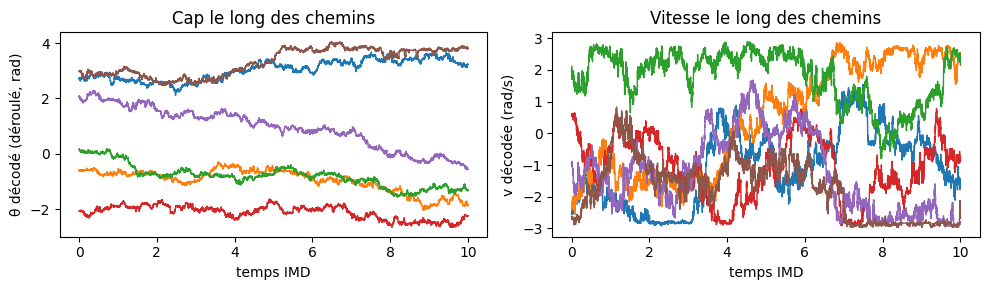

In [9]:
def knn_decode(Z, k=10):
    _, nn = tree.query(Z.reshape(-1, N_PCS), k=k)
    th = np.angle(np.exp(1j * theta_X[nn]).mean(1))
    v = vel_X[nn].mean(1)
    return th.reshape(Z.shape[:-1]), v.reshape(Z.shape[:-1])

_, nn = tree.query(X, k=11)
knn_err = np.angle(np.exp(1j * (np.angle(np.exp(1j * theta_X[nn[:, 1:]]).mean(1)) - theta_X)))
print(f"décodeur kNN (leave-one-out) : erreur médiane |Δθ| = {np.median(np.abs(knn_err)):.3f} rad")

theta_paths, vel_paths = knn_decode(paths)
t_axis = np.arange(N_STEPS + 1) * DT
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
for th_p, v_p in zip(theta_paths, vel_paths):
    axes[0].plot(t_axis, np.unwrap(th_p), lw=1)
    axes[1].plot(t_axis, v_p, lw=1)
axes[0].set(xlabel="temps IMD", ylabel="θ décodé (déroulé, rad)", title="Cap le long des chemins")
axes[1].set(xlabel="temps IMD", ylabel="v décodée (rad/s)", title="Vitesse le long des chemins")
plt.tight_layout()
plt.show()

## 8. Quantitative test: does the angle spread as expected?

The IMD targets $\frac12\Delta$, a Brownian motion on the cylinder. Along the ring (a circle of radius $R$ in PCA space), the arc length travelled has variance $t$, so the angle $\theta=\text{arc}/R$ has a mean squared displacement

$$\text{MSD}_\theta(t) = \frac{t}{R^2}.$$

We measure $R$ on the cloud (mean radius in the PC1–2 plane) and compare with the slope observed on 60 longer paths. Nothing is fitted: this checks that the walker spreads at the right speed (the diffusion rate of a true Brownian motion). The ring is not perfectly round ($R$ varies a bit), so expect agreement within ~10 %, not exact.

rayon du ring R = 3.05 -> pente prédite 1/R² = 0.108
pente observée (t ≤ 10) = 0.074


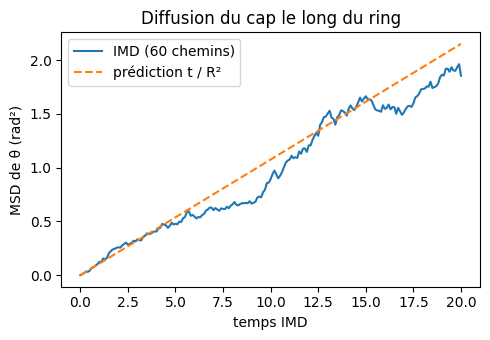

In [10]:
N_MSD_PATHS, N_MSD_STEPS, SUB = 60, 20000, 100
starts = X[np.random.default_rng(2).choice(len(X), N_MSD_PATHS, replace=False)]
long_paths = euler_maruyama(starts, lookup, dt=DT, n_steps=N_MSD_STEPS, seed=11)[:, ::SUB]
theta_long = np.unwrap(knn_decode(long_paths)[0], axis=1)
msd = ((theta_long - theta_long[:, :1]) ** 2).mean(0)
t_long = np.arange(long_paths.shape[1]) * DT * SUB

R = np.linalg.norm(X[:, :2] - X[:, :2].mean(0), axis=1).mean()
fit_range = t_long <= 10
slope = np.polyfit(t_long[fit_range], msd[fit_range], 1)[0]
print(f"rayon du ring R = {R:.2f} -> pente prédite 1/R² = {1 / R**2:.3f}")
print(f"pente observée (t ≤ 10) = {slope:.3f}")

plt.figure(figsize=(5, 3.5))
plt.plot(t_long, msd, label="IMD (60 chemins)")
plt.plot(t_long, t_long / R**2, "--", label="prédiction t / R²")
plt.xlabel("temps IMD")
plt.ylabel("MSD de θ (rad²)")
plt.title("Diffusion du cap le long du ring")
plt.legend()
plt.tight_layout()
plt.show()